# find out why "S-Progress" has a spike when x-axis next to 1

In [2]:
import pandas as pd
import numpy as np
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
df_moves=pd.read_csv('peak.csv')

In [28]:
df_moves.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'uid', 'Move_Idx', 'Player', 'Color', 'E',
       'E1', 'E2', 'E3', 'E4', 'E5', 'Judgment_Raw', 'Is_Error', 'Is_Blunder',
       'Δi', 'Δ', 'ELO', 'ELO_Group', 'Is_Forced', 'Is_Optimal', 'Remain_Time',
       'Time_Group', 'Move_Time', 'Game_Length', 'Progress',
       'Relative_Stage(temp)', 'Delta0_Group', 'P_optimal', 'S',
       'P_optimal(Global=10.0cp)', 'S(Global=10.0cp)',
       'P_optimal(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_optimal(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_optimal(Global=150.0cp)', 'S(Global=150.0cp)', 'Progress_bin'],
      dtype='object')

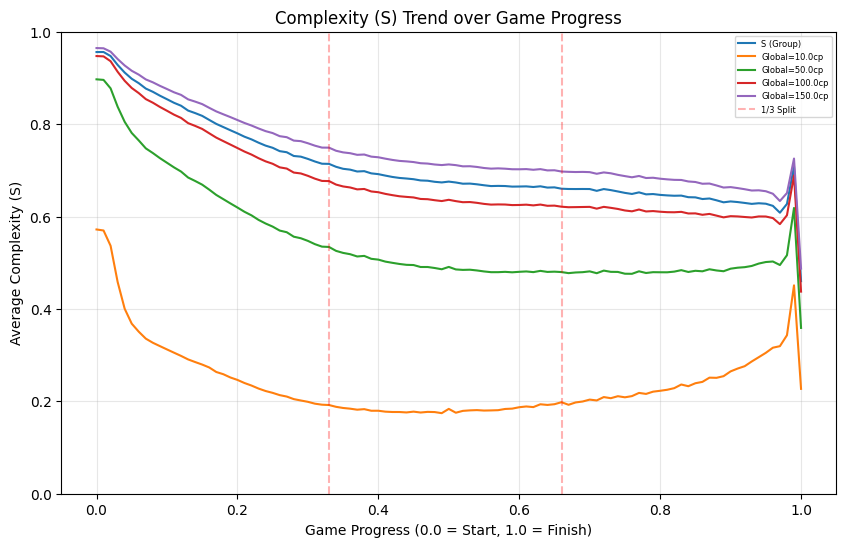

In [6]:
# general round=2 100 bins
plt.figure(figsize=(10, 6))

# 画 Group-specific S
sns.lineplot(
    x=df_moves['Progress'].round(2),
    y=df_moves['S'],
    estimator='mean',
    errorbar=None,
    label='S (Group)'
)

# 自动找所有 Global S 列
global_s_cols = [col for col in df_moves.columns if col.startswith('S(Global=')]

# 画 Global S
for col in global_s_cols:
    sns.lineplot(
        x=df_moves['Progress'].round(2),
        y=df_moves[col],
        estimator='mean',
        errorbar=None,
        label=col.replace('S(', '').replace(')', '')
    )

plt.ylim(0, 1)
plt.title("Complexity (S) Trend over Game Progress")
plt.xlabel("Game Progress (0.0 = Start, 1.0 = Finish)")
plt.ylabel("Average Complexity (S)")
plt.axvline(0.33, color='r', linestyle='--', alpha=0.3, label='1/3 Split')
plt.axvline(0.66, color='r', linestyle='--', alpha=0.3)
plt.legend(fontsize=6)
plt.grid(True, alpha=0.3)
plt.show()


# 2 spike:    
# progress==0.95

In [29]:
# 这里取的是S(Global=100.0cp)列，不能是group sepecific画出的线的尖峰处
progress_rounded = df_moves['Progress'].round(2)
grouped_S = (df_moves.groupby(progress_rounded)['S(Global=100.0cp)'].mean())
# 找最后的尖峰点时先切出来，避免前面的峰顶干扰
late_game_S = grouped_S[grouped_S.index > 0.9]
peak_progress = late_game_S.idxmax()
peak_value = late_game_S.max()
print("Spike Progress:", peak_progress)
print("Spike S(Global=100.0cp) value:", peak_value) 
print("该点的样本量:", {df_moves[progress_rounded == peak_progress].shape[0]}) 

Spike Progress: 0.99
Spike S(Global=100.0cp) value: 0.6889391253595689
该点的样本量: {83578}


# progress at 0.99

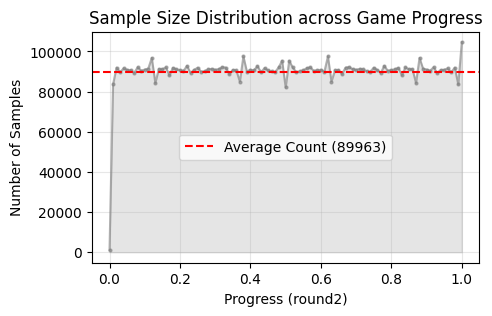

全场平均每个点的样本量: 89963
尖峰点 (0.99) 的样本量: 83578
样本量最充足的点 : 104589 (at Progress 1.0)


In [30]:
# 这段是确保我画图时每个点的样本数量是均匀的，看一下分布检验一下
# 求每个进度点的样本量
counts = df_moves['Progress'].round(2).value_counts().sort_index()
# 画出样本量分布图
plt.figure(figsize=(5, 3))
plt.plot(counts.index, counts.values, marker='o', markersize=2, color='gray', alpha=0.6)
plt.fill_between(counts.index, counts.values, color='gray', alpha=0.2)
plt.axhline(counts.mean(), color='r', linestyle='--', label=f'Average Count ({int(counts.mean())})')
plt.title("Sample Size Distribution across Game Progress")
plt.xlabel("Progress (round2)")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"全场平均每个点的样本量: {int(counts.mean())}")
print(f"尖峰点 (0.99) 的样本量: {counts[0.99]}")
print(f"样本量最充足的点 : {counts.max()} (at Progress {counts.idxmax()})")

In [ ]:
spike_bin_data = df_moves[progress_rounded == 0.99]['S(Global=100.0cp)']
print(spike_bin_data.describe())

count    83578.000000
mean         0.708815
std          0.377715
min         -0.000000
25%          0.478905
50%          0.925479
75%          0.994794
max          1.000000
Name: S, dtype: float64


找到尖峰区之后，要确定为什么0.99时的S值那么高，到底发生啥了。   
找来0.99前后的点

In [40]:
normal_zone = df_moves[df_moves['Progress'].round(2).isin([0.65, 0.66])]
# 对比区间：邻居点 (0.97-0.98, 1.00) vs 尖峰点 (0.99)
left_neighbor_zone = df_moves[df_moves['Progress'].round(2).isin([0.97, 0.98])]
right_neighbor_zone = df_moves[df_moves['Progress'].round(2).isin([1.00])]
spike_zone = df_moves[df_moves['Progress'].round(2) == 0.99]

# 对比核心指标
comparison = pd.DataFrame({
    '指标 (均值)': ['S(Global=100.0cp) (复杂度)', 'Delta(E1与后续Ei的加权分差)', 'E1 (第一好棋分值)'],
    '左邻居点 (0.97-0.98)': [
        left_neighbor_zone['S(Global=100.0cp)'].mean(),
        left_neighbor_zone['Δ'].mean(),
        left_neighbor_zone['E1'].mean()    ],
    '右邻居点1.00':[
        right_neighbor_zone['S(Global=100.0cp)'].mean(),
        right_neighbor_zone['Δ'].mean(),
        right_neighbor_zone['E1'].mean()    ],
    '尖峰点 (0.99)': [
        spike_zone['S(Global=100.0cp)'].mean(),
        spike_zone['Δ'].mean(),
        spike_zone['E1'].mean()    ],
    '普通组':[
        normal_zone['S(Global=100.0cp)'].mean(),
        normal_zone['Δ'].mean(),
        normal_zone['E1'].mean()    ]
})

print(comparison)
print(f"尖峰点 (0.99) 的样本量: {counts[0.99]}")
print(f"左邻居 (0.97-0.98) 的样本量: {counts[0.97]}+{counts[0.98]}")
print(f"右邻居 (1.00) 的样本量: {counts[1.00]}")

                   指标 (均值)  左邻居点 (0.97-0.98)     右邻居点1.00  尖峰点 (0.99)  \
0  S(Global=100.0cp) (复杂度)          0.593262     0.437464    0.688939   
1      Delta(E1与后续Ei的加权分差)       1046.228080  1935.497509  908.541494   
2              E1 (第一好棋分值)        184.451484   326.011043  164.773792   

          普通组  
0    0.622428  
1  222.965586  
2   28.674039  
尖峰点 (0.99) 的样本量: 83578
左邻居 (0.97-0.98) 的样本量: 89656+91934
右邻居 (1.00) 的样本量: 104589


$Mean(S) \neq f(Mean(\Delta))$

In [39]:
spike_zone[['uid', 'E',
       'E1', 'E2', 'E3', 'E4', 'E5',
       'Δi', 'Δ', 'Is_Forced', 'Is_Optimal', 
       'Time_Group','Progress', 'Delta0_Group', 'P_optimal', 'S',
       'P_optimal(Global=100.0cp)', 'S(Global=100.0cp)', 'Progress_bin']].head(20)

,uid,E,E1,E2,E3,E4,E5,Δi,Δ,Is_Forced,Is_Optimal,Time_Group,Progress,Delta0_Group,P_optimal,S,P_optimal(Global=100.0cp),S(Global=100.0cp),Progress_bin
949,49,9981,9981,9998,9999,__MISSING__,__MISSING__,0.0,17.0,0,1,Middle (70-170),0.989899,122.5,0.534638,9.033649e-01,0.542398,8.825764e-01,49
1021,50,-732,-696,-696,-700,-700,-707,36.0,3.0,0,0,Middle (70-170),0.986111,138.3,0.505423,9.844374e-01,0.507499,9.785219e-01,49
1153,52,-221,-293,-291,-257,-252,-242,72.0,25.0,0,0,Middle (70-170),0.987952,113.3,0.554941,8.495949e-01,0.562177,8.309049e-01,49
1402,56,382,286,336,369,372,373,96.0,71.0,0,0,Middle (70-170),0.988506,122.5,0.640973,6.416634e-01,0.670401,5.769034e-01,49
1481,57,637,641,9990,__MISSING__,__MISSING__,__MISSING__,-4.0,9349.0,0,1,Extremely Tense (0-15),0.987342,138.3,1.000000,-0.000000e+00,1.000000,-0.000000e+00,49
1609,59,515,509,529,535,535,538,6.0,24.0,0,1,Extremely Tense (0-15),0.985075,122.5,0.548824,8.655858e-01,0.559714,8.372392e-01,49
2246,71,-639,-464,-470,-476,-484,-486,175.0,12.0,0,0,Tense (15-70),0.986842,122.5,0.524470,9.310672e-01,0.529964,9.160336e-01,49
2440,74,960,569,569,955,__MISSING__,__MISSING__,391.0,165.0,0,0,Tense (15-70),0.986301,122.5,0.793629,3.334639e-01,0.838891,2.534446e-01,49
2509,75,9997,9997,__MISSING__,__MISSING__,__MISSING__,__MISSING__,0.0,0.0,1,1,Extremely Tense (0-15),0.985507,122.5,0.500000,1.000000e+00,0.500000,1.000000e+00,49
2977,83,0,0,0,0,24,31,0.0,8.0,0,1,Tense (15-70),0.985915,122.5,0.516321,9.536606e-01,0.519989,9.434460e-01,49


In [41]:
left_neighbor_zone[['uid', 'E',
       'E1', 'E2', 'E3', 'E4', 'E5',
       'Δi', 'Δ', 'Is_Forced', 'Is_Optimal', 
       'Time_Group','Progress', 'Delta0_Group', 'P_optimal', 'S',
       'P_optimal(Global=100.0cp)', 'S(Global=100.0cp)', 'Progress_bin']].head(20)

,uid,E,E1,E2,E3,E4,E5,Δi,Δ,Is_Forced,Is_Optimal,Time_Group,Progress,Delta0_Group,P_optimal,S,P_optimal(Global=100.0cp),S(Global=100.0cp),Progress_bin
60,34,9990,9989,570,545,531,487,-1.0,9443.0,0,1,Middle (70-170),0.968254,113.3,1.000000,-0.000000e+00,1.000000,-0.000000e+00,48
61,34,9997,9990,9997,9997,__MISSING__,__MISSING__,7.0,7.0,0,1,Tense (15-70),0.984127,122.5,0.514282,9.593689e-01,0.517493,9.503891e-01,49
116,35,9997,9997,9997,9997,9999,9999,0.0,1.0,0,1,Tense (15-70),0.981818,122.5,0.502041,9.941235e-01,0.502500,9.928046e-01,49
170,36,-491,-327,-331,-346,-348,-359,164.0,15.0,0,0,Tense (15-70),0.981481,122.5,0.530574,9.143740e-01,0.537430,8.958517e-01,49
219,37,9998,858,858,957,9987,9990,9140.0,2769.0,0,0,Tense (15-70),0.979592,138.3,1.000000,2.909807e-09,1.000000,1.360175e-12,48
283,38,352,362,332,312,283,261,10.0,53.0,0,1,Middle (70-170),0.969231,113.3,0.614859,7.016718e-01,0.629483,6.677604e-01,48
284,38,411,352,389,392,404,405,59.0,43.0,0,0,Middle (70-170),0.984615,122.5,0.586865,7.688994e-01,0.605874,7.229111e-01,49
333,39,199,182,196,318,379,395,17.0,107.0,0,0,Tense (15-70),0.979592,122.5,0.705467,5.033493e-01,0.744597,4.254685e-01,48
394,40,-175,-189,-182,-176,-172,-93,14.0,20.0,0,0,Middle (70-170),0.967742,105.3,0.547341,8.694878e-01,0.549834,8.629320e-01,48
395,40,-544,-175,-176,-184,-184,-195,369.0,7.0,0,0,Tense (15-70),0.983871,122.5,0.514282,9.593689e-01,0.517493,9.503891e-01,49


In [42]:
right_neighbor_zone[['uid', 'E',
       'E1', 'E2', 'E3', 'E4', 'E5',
       'Δi', 'Δ', 'Is_Forced', 'Is_Optimal', 
       'Time_Group','Progress', 'Delta0_Group', 'P_optimal', 'S',
       'P_optimal(Global=100.0cp)', 'S(Global=100.0cp)', 'Progress_bin']].head(20)

,uid,E,E1,E2,E3,E4,E5,Δi,Δ,Is_Forced,Is_Optimal,Time_Group,Progress,Delta0_Group,P_optimal,S,P_optimal(Global=100.0cp),S(Global=100.0cp),Progress_bin
62,34,9997,9997,9996,9991,9988,734,0.0,930.0,0,1,Middle (70-170),1.0,113.3,0.999728,0.000393,0.999909,0.000132,49
117,35,9997,9997,9996,509,474,13,0.0,5750.0,0,1,Middle (70-170),1.0,113.3,1.000000,-0.000000,1.000000,-0.000000,49
171,36,-504,-491,-392,-372,-350,-333,-13.0,119.0,0,1,Middle (70-170),1.0,105.3,0.755858,0.403813,0.766741,0.383189,49
220,37,9999,9998,553,505,446,439,-1.0,9492.0,0,1,Middle (70-170),1.0,118.5,1.000000,-0.000000,1.000000,-0.000000,49
285,38,398,411,147,133,115,__MISSING__,13.0,276.0,0,0,Middle (70-170),1.0,113.3,0.919532,0.121028,0.940476,0.088538,49
334,39,192,199,-447,-462,-481,-497,7.0,662.0,0,1,Middle (70-170),1.0,105.3,0.998143,0.002682,0.998668,0.001922,49
396,40,-539,-544,-539,-475,-200,-193,5.0,127.0,0,1,Middle (70-170),1.0,105.3,0.769604,0.377811,0.780743,0.357081,49
457,41,0,9999,9997,0,0,-79,9999.0,6008.0,0,0,Middle (70-170),1.0,118.5,1.000000,-0.000000,1.000000,-0.000000,49
510,42,451,459,-369,-447,-512,-534,8.0,897.0,0,1,Middle (70-170),1.0,105.3,0.999800,0.000288,0.999873,0.000183,49
570,43,-423,-425,-185,-172,-150,-120,2.0,257.0,0,1,Middle (70-170),1.0,105.3,0.919875,0.120491,0.928906,0.106396,49
